# Socio-economic Drivers of Antibiotic Precribing: A Machine Learning Approach
## objective: 
### To analyze the impact of socio-economic determinants (eg., deprivation, demographics,GP density, COPD prevalence, ethnicity) on antibiotic prescribing behaviors across NHS Sub-ICBs locations. 

## 1.Data acquisition from NHS Fingertips API

**Objective:** Retrieve Real-World Data on antibiotic utilization from NHS England's public health database.    
**Methodology:**
* **Data Source:** NHS Fingertips API (Public health Profiles)
* **Indicators Selected:**
    * *ID 92163*: Total Antibiotics Prescribing (DDD per 1000 patients)
    * *ID 92167*: Broad-spectrum antibiotic prescribing (Quality indicator).
* **Granularity:** Sub-ICB Locations (Area Type ID: 66).


In [ ]:
%pip install fingertips_py

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import fingertips_py as ftp

In [ ]:
print(dir(ftp))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'api_calls', 'area_data', 'deprivation_decile', 'get_age_from_id', 'get_age_id', 'get_all_ages', 'get_all_areas', 'get_all_areas_for_all_indicators', 'get_all_data_for_indicators', 'get_all_data_for_profile', 'get_all_profiles', 'get_all_sexes', 'get_all_value_notes', 'get_area_type_ids_for_profile', 'get_area_types_as_dict', 'get_area_types_for_profile', 'get_areas_for_area_type', 'get_data_by_indicator_ids', 'get_data_for_indicator_at_all_available_geographies', 'get_domains_in_profile', 'get_json', 'get_metadata', 'get_metadata_for_all_indicators', 'get_metadata_for_all_indicators_from_csv', 'get_metadata_for_domain_as_dataframe', 'get_metadata_for_indicator', 'get_metadata_for_indicator_as_dataframe', 'get_metadata_for_profile_as_dataframe', 'get_multiplier_and_calculation_for_indicator', 'get_profile_by_id', 'get_profile_by_name', 'get_sex_from_id',

In [ ]:
df=ftp.get_data_by_indicator_ids(
    indicator_ids=[92163,92167],
    area_type_id=66
)
df.to_csv("antibiotics_data.csv", index=False)

## 2.Features Engineering Antibiotic data

**Objective:** To transform raw time-series data into a structured dataset reflecting prescribing behavior.   

**Key Features Constructed:**   
1.  **Volume (Magnitude):** Total antibiotic prescribing volume (Standardized as DDD per 1000 patients).
2.  **Quality (Composition):** The proportion of broad-spectrum antibiotics relative to total prescribing. 
3.  **Seasonality:** Ratio of winter consumption (Q4/Q1) to summer consumption (Q3/Q2).
4.  **Trend:** Percentage change in prescribing volume compared to the same period last year.

**Data Transformation:**
* **Pivoting:** Reshaping data from long format to wide format to create a unified feature matrix for clustering.


In [5]:
import pandas as pd
%pip install "numpy<2.0"
import numpy as np

Note: you may need to restart the kernel to use updated packages.


In [6]:
print(np.__version__)

1.26.4


In [7]:
current_year = ['2024 Q3','2024 Q4','2025 Q1','2025 Q2']
last_year = ['2023 Q3','2023 Q4','2024 Q1','2024 Q2']

df_filtered = df[
    (df['Area Type'] == 'ICB sub-locations') &
    (df['Time period'].isin(current_year + last_year)) &
    (df['Indicator ID'].isin([92163,92167]))
].copy()

In [8]:
df_filtered['Metric'] = df_filtered['Indicator ID'].map({
    92163:'Qty',
    92167:'Quality'
})
df_wide = df_filtered.pivot_table(
    index=['Area Code', 'Area Name'],
    columns=['Metric','Time period'],
    values='Value'
)

df_wide.columns = [f"{metric}_{period}" for metric, period in df_wide.columns]
df_wide = df_wide.reset_index()

In [9]:
df_wide['Qty_Mean_Current'] = df_wide[['Qty_2024 Q3', 'Qty_2024 Q4', 'Qty_2025 Q1', 'Qty_2025 Q2']].mean(axis=1)
df_wide['Quality_Mean_Current'] = df_wide[['Quality_2024 Q3', 'Quality_2024 Q4', 'Quality_2025 Q1', 'Quality_2025 Q2']].mean(axis=1)
winter = df_wide[['Qty_2024 Q4', 'Qty_2025 Q1']].mean(axis=1)
summer = df_wide[['Qty_2024 Q3', 'Qty_2025 Q2']].mean(axis=1)
df_wide['Seasonality'] = winter / summer
df_wide['Qty_Mean_Last'] = df_wide[['Qty_2023 Q3', 'Qty_2023 Q4', 'Qty_2024 Q1', 'Qty_2024 Q2']].mean(axis=1)
df_wide['Quantity_Trend'] = ((df_wide['Qty_Mean_Current'] - df_wide['Qty_Mean_Last']) / df_wide['Qty_Mean_Last'] * 100)



In [10]:
df_wide['SUB_ICB_Code'] = df_wide['Area Name'].str.split('-').str[-1].str.strip()
final_cols = [
    'Area Code', 'Area Name', 'SUB_ICB_Code',
    'Qty_Mean_Current', 
    'Quality_Mean_Current',
    'Seasonality', 
    'Quantity_Trend'
]
df_final = df_wide[final_cols]


In [11]:
df_final.to_csv('antibiotics_features.csv',index=False)


## 3.Unsupervised Learning: identifying prescribing types

**Objective:** To address heterogeneity in the population by identifying distinct Prescribing Clusters.

**Methodology:**
* **Algorithm:** K-Means Clustering.
* **Input Features:** Standardized behavioral metrics (Volume, Quality, Seasonality, Trend).
* **Rationale:** Antibiotic prescribing is not uniform. Grouping Sub-ICBs with similar behaviors allows for more accurate, group-specific attribution analysis in the subsequent supervised learning stage.

In [12]:
%pip install scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [13]:

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv('antibiotics_features.csv')
features = ['Qty_Mean_Current', 'Quality_Mean_Current', 'Seasonality', 'Quantity_Trend']
X = df[features] 

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

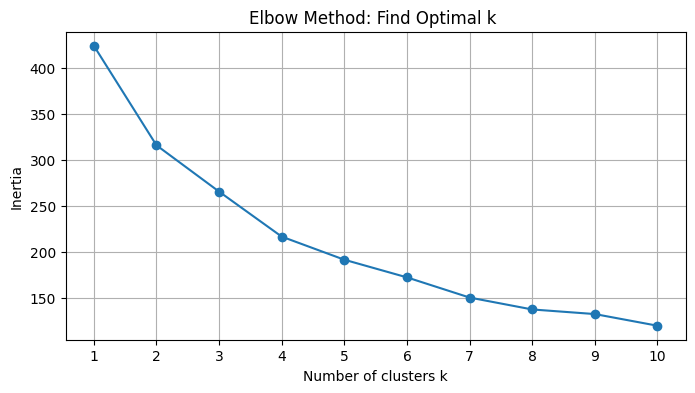

In [16]:
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42,n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertia, marker='o' )
plt.title('Elbow Method: Find Optimal k ')
plt.xlabel('Number of clusters k')
plt.ylabel('Inertia')
plt.xticks(K)
plt.grid()
plt.savefig('elbow_plot.png')
plt.show()

In [17]:
for k, value in enumerate(inertia,1):
    print(f'k={k}, inertia={value}')

k=1, inertia=424.00000000000006
k=2, inertia=315.9075998387784
k=3, inertia=265.57482050835256
k=4, inertia=216.6915055053373
k=5, inertia=191.61044011155417
k=6, inertia=172.4342938018095
k=7, inertia=150.53410803080197
k=8, inertia=137.60436580035386
k=9, inertia=132.60155699142248
k=10, inertia=119.94459280933131


#### K=4

In [18]:
kmeans = KMeans(n_clusters=4, random_state=42,n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)


In [19]:
cluster_summary = df.groupby('Cluster')[features].mean()
print(cluster_summary)

print(df['Cluster'].value_counts().sort_index())


         Qty_Mean_Current  Quality_Mean_Current  Seasonality  Quantity_Trend
Cluster                                                                     
0              126.521337              6.574632     1.157156       -8.599607
1              100.081073              8.270968     1.207769       -8.421561
2              109.295400              6.770294     1.172616      -13.314567
3              130.209985              9.380417     1.206909       -8.500396
Cluster
0    34
1    31
2    17
3    24
Name: count, dtype: int64


In [20]:
df.to_csv('antibiotics_clustered.csv',index=False)  


In [21]:
from sklearn.decomposition import PCA

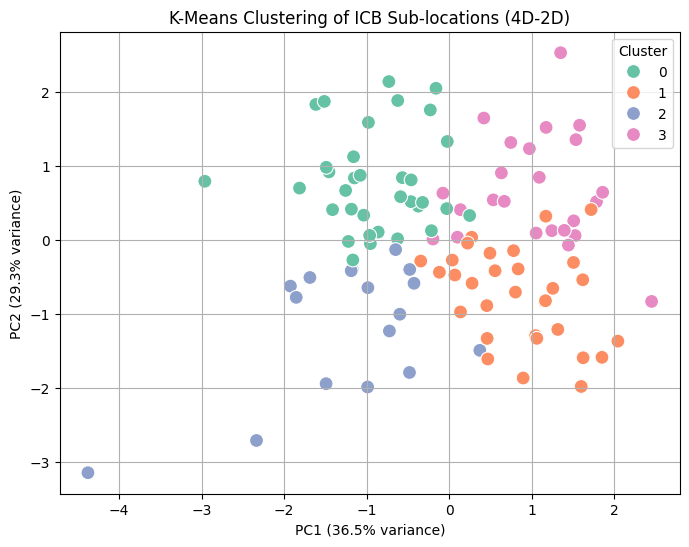

In [22]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PC1']= X_pca[:,0]
df['PC2']= X_pca[:,1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PC1', y='PC2', hue='Cluster', palette='Set2', s=100)
plt.title('K-Means Clustering of ICB Sub-locations (4D-2D)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.grid(True)
plt.savefig('kmeans_clusters_pca.png')
plt.show()

In [23]:
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=features)
print("PCA Loadings:")
print(loadings)

PCA Loadings:
                           PC1       PC2
Qty_Mean_Current     -0.116151  0.799168
Quality_Mean_Current  0.604651 -0.030550
Seasonality           0.655645 -0.206122
Quantity_Trend        0.437076  0.563836


x-axis： pca 1：Quality + Seasonality Issue    
y-axis： pca 2: Prescribing Volume + Growth

## 4. Data Intergration & Analytical Dataset Contruction

**Objective:** To construct a comprehensive analytical dataset by linking the identified Clusters with multi-dimensional socio-economic and clinical determinants.

**Methodology:**
* **Data Linkage:** Merging the behavioral clusters (from Module 3) with 6 external datasets.
* **The 6 Selected Determinant :**
    1.  **COPD Prevalence:** Percentage of patients on the COPD register. Proxies for *chronic respiratory clinical need*.
    2.  **Index of Multiple Deprivation (IMD):** Composite score representing the overall socio-economic status and deprivation level of the area.
    3.  **Age 65+ (%):** Proportion of the patients aged 65 and over. Represents the *elderly demographic* vulnerable to severe infections.
    4.  **Age 0-14 (%):** Proportion of the patients aged 0 to 14. Represents the *pediatric demographic*, a key group for respiratory tract infection consultations.
    5.  **Ethnicity (%):** Proportion of population from Black, Asian, and Minority Ethnic (BAME) backgrounds. Captures *cultural/social determinants*.
    6.  **GP Density:** Number of General Practitioners per 1,000 population. Represents *healthcare system capacity* and supply-side factors.

* **Outcome:** A unified feature matrix where each unit is described by its antibiotic consumption, cluster label and these 6 specific predictors.

GP data(3 determinansts: 60+ patient, ~14 patients, GP density)

In [24]:
df_gp = pd.read_csv('General_Practice_level_Detailed.csv')

base_cols = ['SUB_ICB_CODE', 'SUB_ICB_NAME', 'TOTAL_PATIENTS','TOTAL_GP_FTE']
elderly_cols = [
    'MALE_PATIENTS_65TO74', 'MALE_PATIENTS_75TO84', 'MALE_PATIENTS_85PLUS',
    'FEMALE_PATIENTS_65TO74', 'FEMALE_PATIENTS_75TO84', 'FEMALE_PATIENTS_85PLUS'
]

children_cols = [
    'MALE_PATIENTS_0TO4', 'MALE_PATIENTS_5TO14',
    'FEMALE_PATIENTS_0TO4', 'FEMALE_PATIENTS_5TO14'
]
df_subset = df_gp[base_cols + elderly_cols + children_cols].copy()
df_agg = df_subset.groupby(['SUB_ICB_CODE', 'SUB_ICB_NAME']).sum().reset_index()
   

In [25]:
#driver 1: GP density
df_agg['Driver_GP_Density'] = (df_agg['TOTAL_GP_FTE']/df_agg['TOTAL_PATIENTS']) * 1000
#driver 2: elderly porpotion (>65 %)
elderly_sum = df_agg[elderly_cols].sum(axis=1)
df_agg['Driver_Elderly_Pct'] = elderly_sum / df_agg['TOTAL_PATIENTS']
#driver 3: children porpotion (<14 %)
children_sum = df_agg[children_cols].sum(axis=1)
df_agg['Driver_children_Pct'] = children_sum / df_agg['TOTAL_PATIENTS']

df_drivers = df_agg[['SUB_ICB_CODE','Driver_GP_Density','Driver_Elderly_Pct','Driver_children_Pct']]


merge antibiotics_cluster data with GP density + 65+% patients + ~14% patients

In [26]:
df_merged = df.merge( 
    df_drivers,
    left_on = 'SUB_ICB_Code',
    right_on = 'SUB_ICB_CODE',
    how = 'left'
)
df_merged = df_merged.drop(columns=['SUB_ICB_CODE'])

In [27]:
print(df_merged[['Driver_GP_Density', 'Driver_Elderly_Pct', 'Driver_children_Pct']].isnull().sum())

Driver_GP_Density      0
Driver_Elderly_Pct     0
Driver_children_Pct    0
dtype: int64


merge data with COPD

In [28]:
df_copd = pd.read_csv('253_COPD_QOF_prevalence.csv')

df_copd_sub = df_copd[
    (df_copd['Time period'] == '2024/25') & 
    (df_copd['Area Type'] == 'ICB sub-locations')
].copy()

In [29]:
df_copd_sub['SUB_ICB_Code'] = df_copd_sub['Area Name'].str.split('-').str[-1].str.strip()
df_copd_final = df_copd_sub[['SUB_ICB_Code','Value','Parent Code']].rename(columns={'Parent Code':'ICB_Code','Value':'COPD_Prevalence'})

df_merged = df_merged.merge(
    df_copd_final,
    left_on = 'SUB_ICB_Code',
    right_on = 'SUB_ICB_Code',
    how = 'left'
)


merge data with IMD score

In [30]:
df_imd = pd.read_csv('94240_Deprivation score (IMD 2025).csv')


df_imd = df_imd[['Area Code','Value']].rename(columns={'Value':'IMD_Score'} )
df_merged = df_merged.merge(
    df_imd,
    left_on='ICB_Code',
    right_on='Area Code',
    how='left'      
)
df_merged = df_merged.drop(columns=['Area Code_y'])

merge data with ethnicity

In [31]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [32]:
df_eth = pd.read_excel('Ethnic_group_by_religion.xlsx', skiprows=8)
df_eth.columns = ['Name', 'Code', 'Total', 'Asian', 'Black', 'Mixed', 'White', 'Other']

df_eth['SUB_ICB_Code'] = df_eth['Name'].str.split('-').str[-1].str.strip()
df_eth['Minority_Pct'] = ((df_eth['Total'] - df_eth['White']) / df_eth['Total']) * 100
df_eth_final = df_eth[['SUB_ICB_Code', 'Minority_Pct']]

df_merged = df_merged.merge(
    df_eth_final,
    left_on = 'SUB_ICB_Code',
    right_on = 'SUB_ICB_Code',
    how = 'left'
)

In [33]:
df_merged= df_merged[['Area Name','SUB_ICB_Code','ICB_Code','Qty_Mean_Current', 'Quality_Mean_Current', 'Seasonality', 'Quantity_Trend',
                      'PC1','PC2','Cluster','Driver_GP_Density', 'Driver_Elderly_Pct', 'Driver_children_Pct','COPD_Prevalence','IMD_Score','Minority_Pct']]
df_merged.to_csv('antibiotics_features_drivers.csv', index=False)  

## Supervised Learning & SHAP Attribution

**Objective:** To quantify the contribution of specific determinants to antibiotic prescribing and, importantly, to uncover how the ranking of these drivers varies across the identified clusters. 

**Methodology:**
1.  **Random Forest Modeling:**
    * **Model:** Random Forest Regressor trained on the unified dataset.
    * **Input Features:** COPD, IMD, Age 65+, Age 0-14, Ethnicity, GP Density.
    * **Target:** Antibiotic Prescribing Volume
2.  **SHAP (Shapley Additive Explanations) Analysis:**
    * **Global Feature Importance:** what is the overall hierarchy of drivers across the entire nation? 
    * **Cluster-Specific Driver Heterogeneity:**   
    **stratified analysis:** analyze determinants within each specific behavioral group independently.   
    **rank comparison:** compare the feature importance rankings across clusters to identify context-specific mechanisms.


In [34]:
from sklearn.ensemble import RandomForestRegressor
import shap 

/Users/enhe/Library/CloudStorage/OneDrive-UniversityofBergen/R&D/UK antibiotic/UK_antibiotic_XML/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [35]:
df = pd.read_csv('antibiotics_features_drivers.csv')
features =['Driver_GP_Density', 'Driver_Elderly_Pct', 'Driver_children_Pct','COPD_Prevalence','IMD_Score','Minority_Pct']
target = 'Qty_Mean_Current'
X = df[features]
y = df[target]

Uk_Sub = RandomForestRegressor(n_estimators=100, random_state=42)
Uk_Sub.fit(X, y)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [36]:
r2_score = Uk_Sub.score(X, y)
print(f'R² Score on training data: {r2_score:.4f}')


R² Score on training data: 0.9412


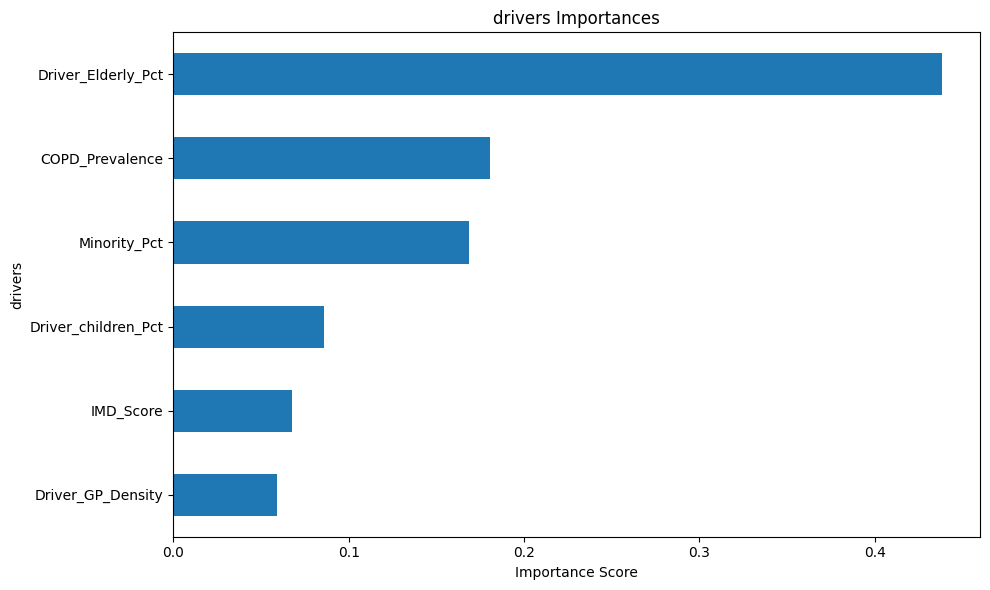

In [37]:
importances = pd.Series(Uk_Sub.feature_importances_, index=features).sort_values()
plt.figure(figsize=(10,6))
importances.plot(kind='barh')
plt.title('drivers Importances')
plt.xlabel('Importance Score')
plt.ylabel('drivers')
plt.tight_layout()
plt.savefig('drivers_importance.png')
plt.show()

In [40]:
explainer = shap.TreeExplainer(Uk_Sub)
shap_values = explainer.shap_values(X)

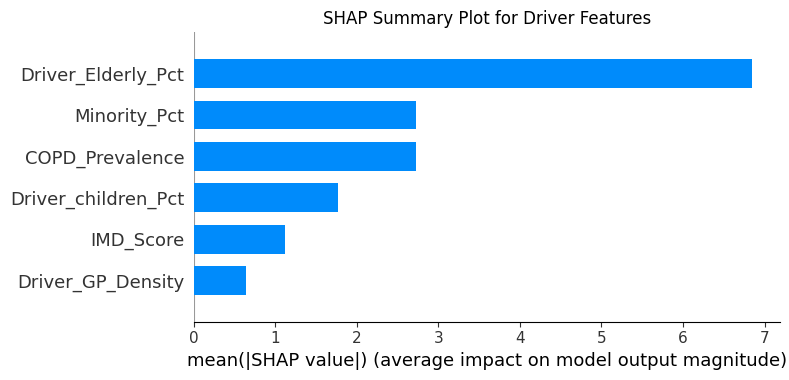

In [41]:
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X, plot_type="bar", show=False)
plt.title('SHAP Summary Plot for Driver Features')
plt.tight_layout()
plt.savefig('shap_summary_plot.png')

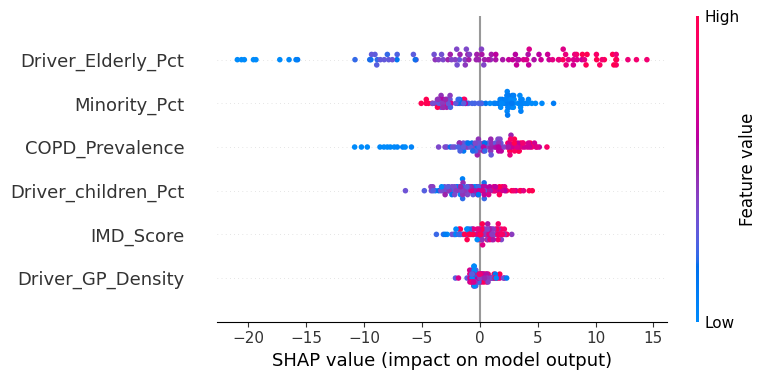

In [42]:
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X, show=False)
plt.savefig('UK_SUB_SHAP_dot.png')

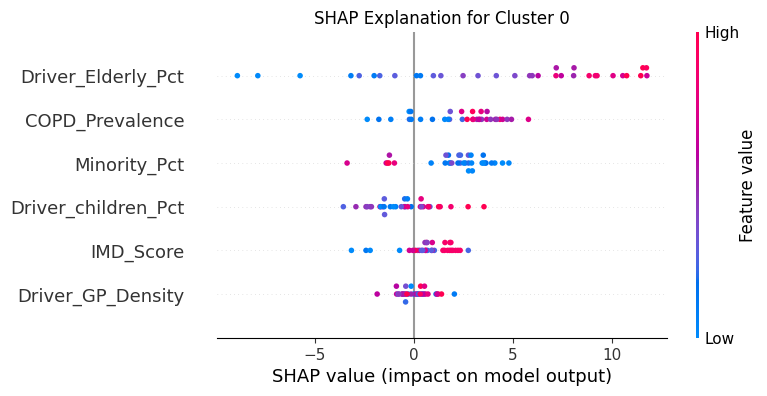

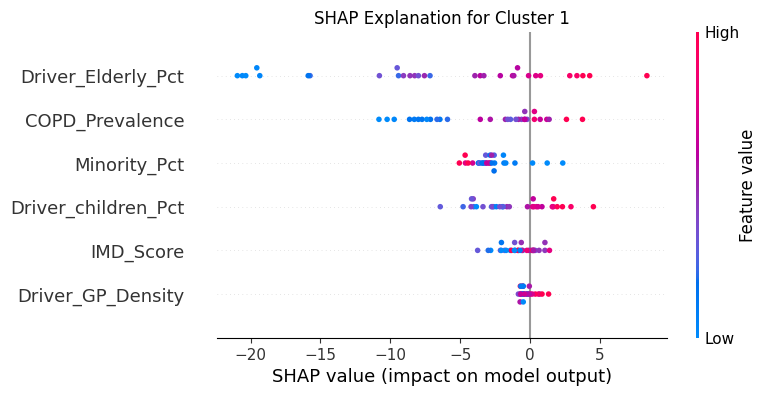

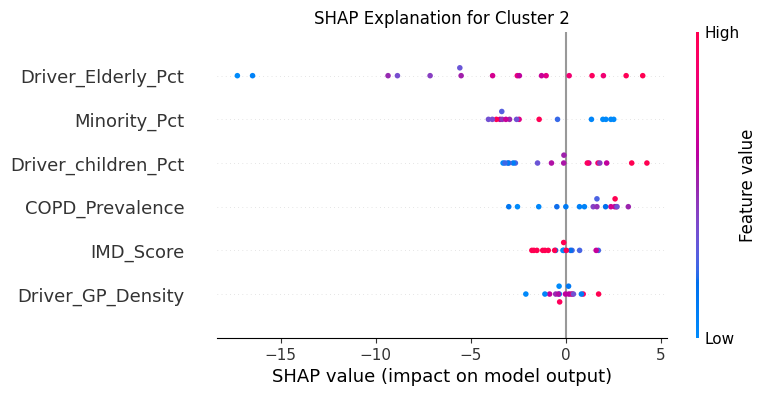

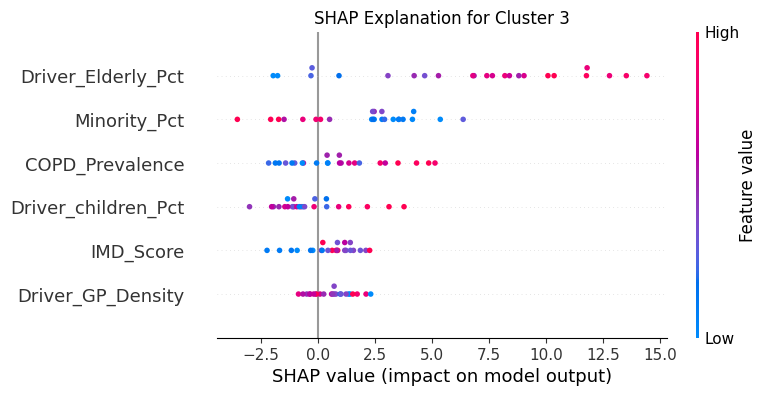

In [43]:
for i in range(4):
    cluster_indices = df[df['Cluster'] == i].index
    cluster_shap = shap_values[cluster_indices]
    cluster_X = X.iloc[cluster_indices]

    plt.figure(figsize=(10,6))
    shap.summary_plot(cluster_shap,cluster_X,show=False)
    plt.title(f'SHAP Explanation for Cluster {i}')
    file_name = f'04_cluster_{i}_SHAP_dot.png'
    plt.savefig(file_name)